# Avocado Price Prediction — Exploratory Data Analysis

We explore the **Hass Avocado Board** weekly retail dataset (2015–2018) to find which features drive the average retail price per avocado.

**Dataset**: 18,249 weekly observations across 54 US regions, conventional and organic types, with PLU-coded volume columns and the regression target `AveragePrice` (USD).

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

%matplotlib inline

## 2. Load Data

In [2]:
df = pd.read_csv("data/avocado.csv")
df = df.drop(columns=["Unnamed: 0"], errors="ignore")
df["Date"] = pd.to_datetime(df["Date"])
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (18249, 13)


,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


**Column glossary** (PLU = Price Look-Up code):
- `4046` — small Hass avocados
- `4225` — medium/large Hass avocados
- `4770` — extra-large Hass avocados
- `Total Volume` — sum of all PLU volumes + bagged sales
- `Total Bags` / `Small Bags` / `Large Bags` / `XLarge Bags` — pre-bagged sales
- `type` — `conventional` or `organic`
- `region` — 54 US sub-markets (states + metro areas + national totals)

## 3. Dataset Overview

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18249 entries, 0 to 18248
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          18249 non-null  datetime64[ns]
 1   AveragePrice  18249 non-null  float64       
 2   Total Volume  18249 non-null  float64       
 3   4046          18249 non-null  float64       
 4   4225          18249 non-null  float64       
 5   4770          18249 non-null  float64       
 6   Total Bags    18249 non-null  float64       
 7   Small Bags    18249 non-null  float64       
 8   Large Bags    18249 non-null  float64       
 9   XLarge Bags   18249 non-null  float64       
 10  type          18249 non-null  object        
 11  year          18249 non-null  int64         
 12  region        18249 non-null  object        
dtypes: datetime64[ns](1), float64(9), int64(1), object(2)
memory usage: 1.8+ MB


In [4]:
df.describe(include='all').round(2)

,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
count,18249,18249.00,18249.00,18249.00,18249.00,18249.00,18249.00,18249.00,18249.00,18249.00,18249,18249.00,18249
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,54
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,conventional,NaN,Albany
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9126,NaN,338
mean,2016-08-13 23:30:43.498273792,1.41,850644.01,293008.42,295154.57,22839.74,239639.20,182194.69,54338.09,3106.43,NaN,2016.15,NaN
min,2015-01-04 00:00:00,0.44,84.56,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN,2015.00,NaN
25%,2015-10-25 00:00:00,1.10,10838.58,854.07,3008.78,0.00,5088.64,2849.42,127.47,0.00,NaN,2015.00,NaN
50%,2016-08-14 00:00:00,1.37,107376.76,8645.30,29061.02,184.99,39743.83,26362.82,2647.71,0.00,NaN,2016.00,NaN
75%,2017-06-04 00:00:00,1.66,432962.29,111020.20,150206.86,6243.42,110783.37,83337.67,22029.25,132.50,NaN,2017.00,NaN
max,2018-03-25 00:00:00,3.25,62505646.52,22743616.17,20470572.61,2546439.11,19373134.37,13384586.80,5719096.61,551693.65,NaN,2018.00,NaN


In [5]:
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Date range    : {df['Date'].min()} → {df['Date'].max()}")
print(f"Regions       : {df['region'].nunique()}")
print(f"Type counts   : {df['type'].value_counts().to_dict()}")

Duplicate rows: 0
Date range    : 2015-01-04 00:00:00 → 2018-03-25 00:00:00
Regions       : 54
Type counts   : {'conventional': 9126, 'organic': 9123}


## 4. Missing / Invalid Values

In [6]:
print(f"Missing values: {df.isnull().sum().sum()}")

Missing values: 0


## 5. Target Variable Distribution

`AveragePrice` is a per-unit price, typically $0.50–$3.00. Mildly right-skewed.

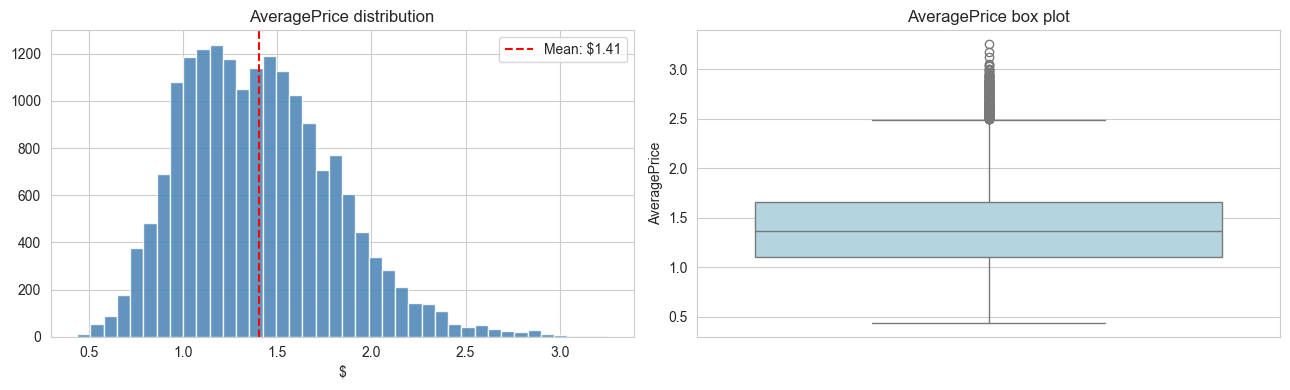

Skewness: 0.58
Range   : $0.44 → $3.25


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(df["AveragePrice"], bins=40, color="steelblue", edgecolor="white", alpha=0.85)
axes[0].axvline(df["AveragePrice"].mean(), color="red", linestyle="--",
                label=f"Mean: ${df['AveragePrice'].mean():.2f}")
axes[0].set_title("AveragePrice distribution"); axes[0].set_xlabel("$"); axes[0].legend()

sns.boxplot(y=df["AveragePrice"], ax=axes[1], color="lightblue")
axes[1].set_title("AveragePrice box plot")
plt.tight_layout(); plt.show()
print(f"Skewness: {df['AveragePrice'].skew():.2f}")
print(f"Range   : ${df['AveragePrice'].min():.2f} → ${df['AveragePrice'].max():.2f}")

## 6. Univariate — Numeric Features

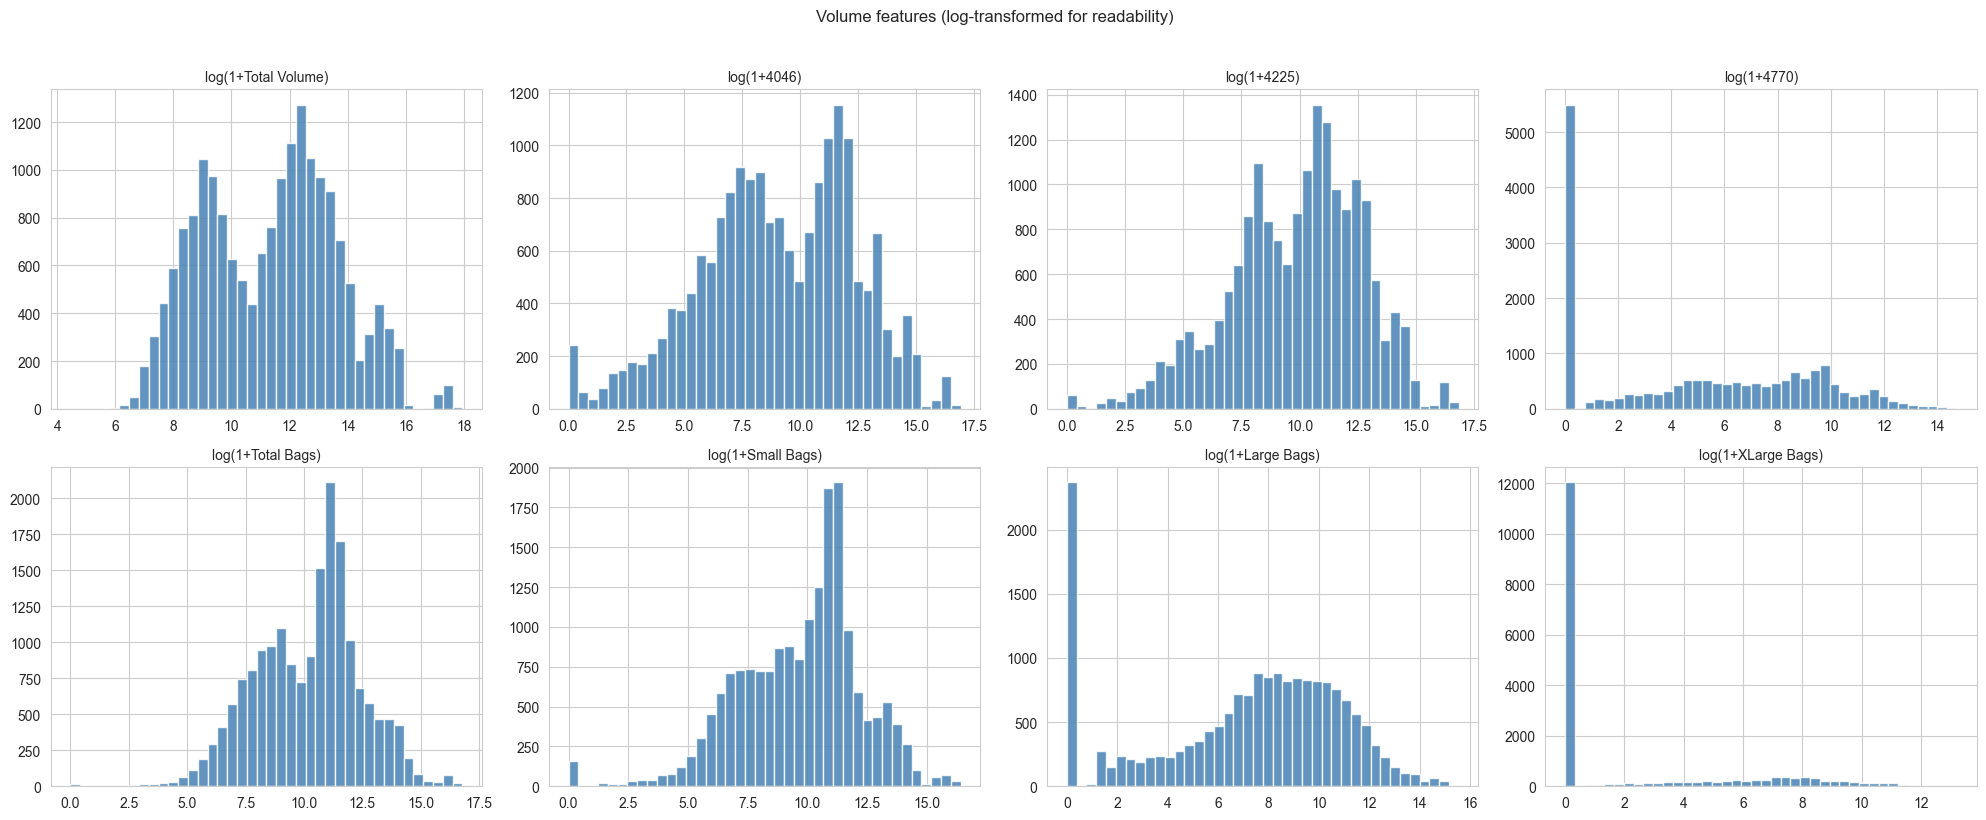

Volume features are heavily right-skewed (warehouse counts).


In [8]:
volume_cols = ["Total Volume","4046","4225","4770","Total Bags","Small Bags","Large Bags","XLarge Bags"]
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()
for i, col in enumerate(volume_cols):
    np.log1p(df[col]).hist(bins=40, color="steelblue", edgecolor="white", alpha=0.85, ax=axes[i])
    axes[i].set_title(f"log(1+{col})", fontsize=10)
plt.suptitle("Volume features (log-transformed for readability)", y=1.02)
plt.tight_layout(); plt.show()
print("Volume features are heavily right-skewed (warehouse counts).")

## 7. Univariate — Categorical / Time Features

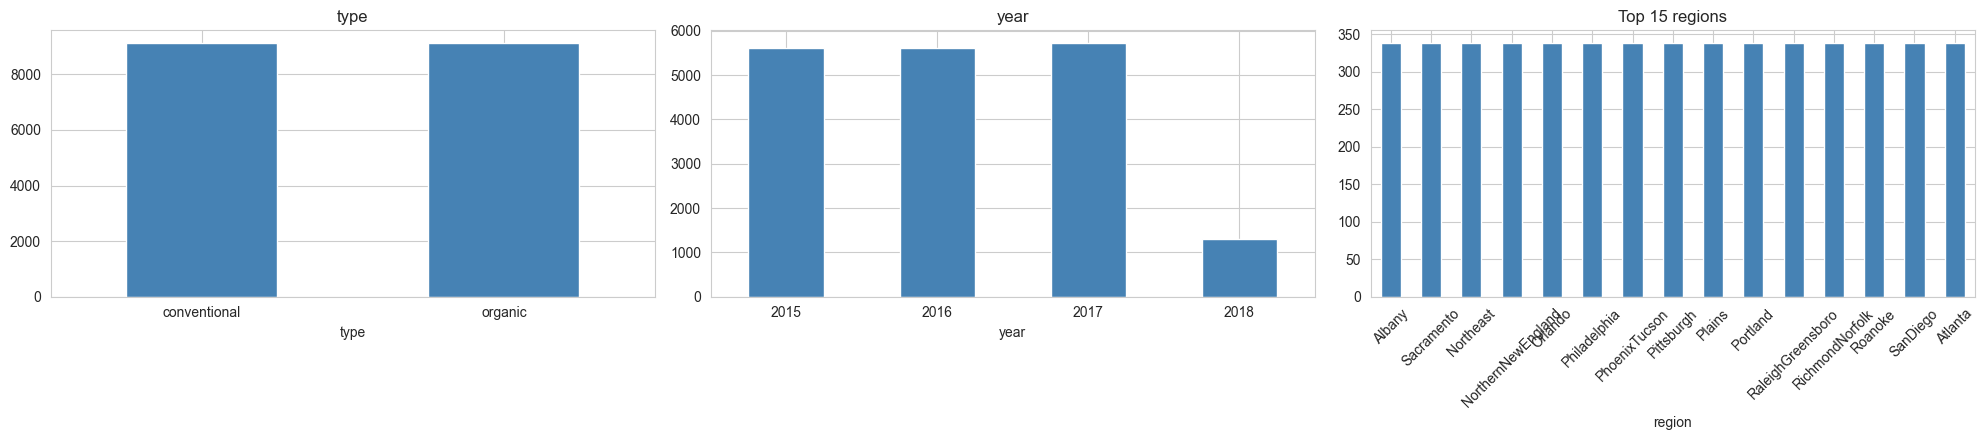

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(20, 4.5))
df["type"].value_counts().plot(kind="bar", color="steelblue", ax=axes[0])
axes[0].set_title("type"); axes[0].tick_params(axis="x", rotation=0)

df["year"].value_counts().sort_index().plot(kind="bar", color="steelblue", ax=axes[1])
axes[1].set_title("year"); axes[1].tick_params(axis="x", rotation=0)

# Top-15 regions by row count
df["region"].value_counts().head(15).plot(kind="bar", color="steelblue", ax=axes[2])
axes[2].set_title("Top 15 regions"); axes[2].tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

## 8. Bivariate — Type and Year vs Price

Organic avocados are systematically more expensive than conventional ones.

/var/folders/3t/st_qgzrd3957m1htwzrz0pkc0000gn/T/ipykernel_72438/4200067783.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="type", y="AveragePrice", data=df, palette="Set2", ax=axes[0])
/var/folders/3t/st_qgzrd3957m1htwzrz0pkc0000gn/T/ipykernel_72438/4200067783.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="year", y="AveragePrice", data=df, palette="Set2", ax=axes[1])


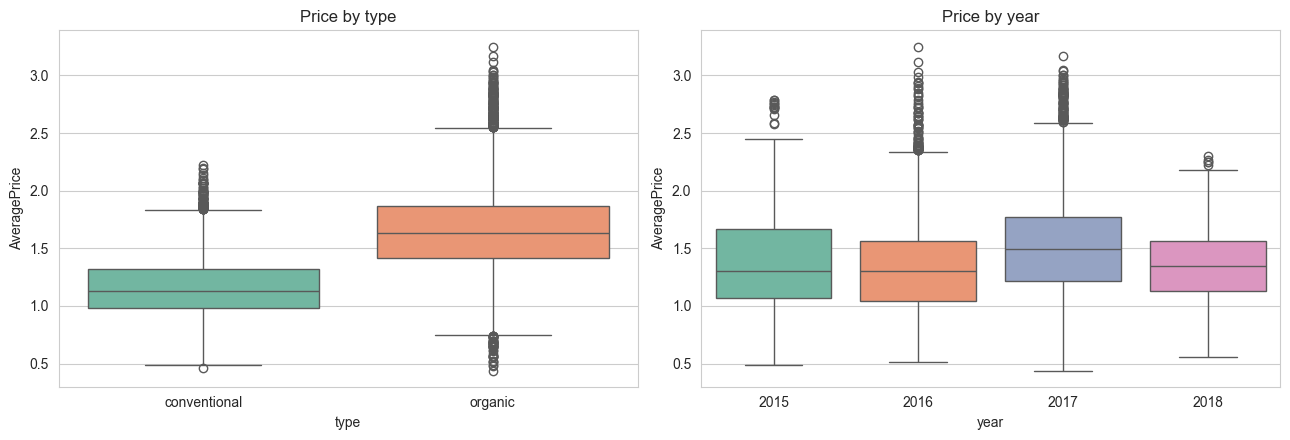

Mean price by type:
               mean  median  count
type                              
conventional  1.158    1.13   9126
organic       1.654    1.63   9123


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.boxplot(x="type", y="AveragePrice", data=df, palette="Set2", ax=axes[0])
axes[0].set_title("Price by type")

sns.boxplot(x="year", y="AveragePrice", data=df, palette="Set2", ax=axes[1])
axes[1].set_title("Price by year")
plt.tight_layout(); plt.show()
print("Mean price by type:")
print(df.groupby("type")["AveragePrice"].agg(["mean","median","count"]).round(3))

## 9. Time Series of Mean Price

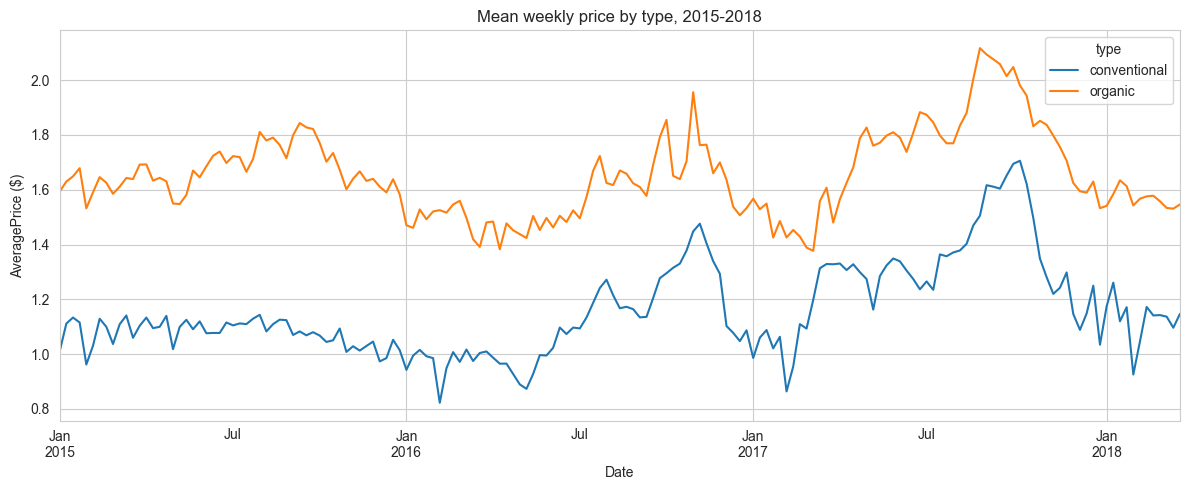

In [11]:
ts = df.groupby(["Date","type"])["AveragePrice"].mean().unstack()
plt.figure(figsize=(12, 5))
ts.plot(ax=plt.gca())
plt.title("Mean weekly price by type, 2015-2018")
plt.ylabel("AveragePrice ($)")
plt.tight_layout(); plt.show()

## 10. Region Effects (top vs bottom)

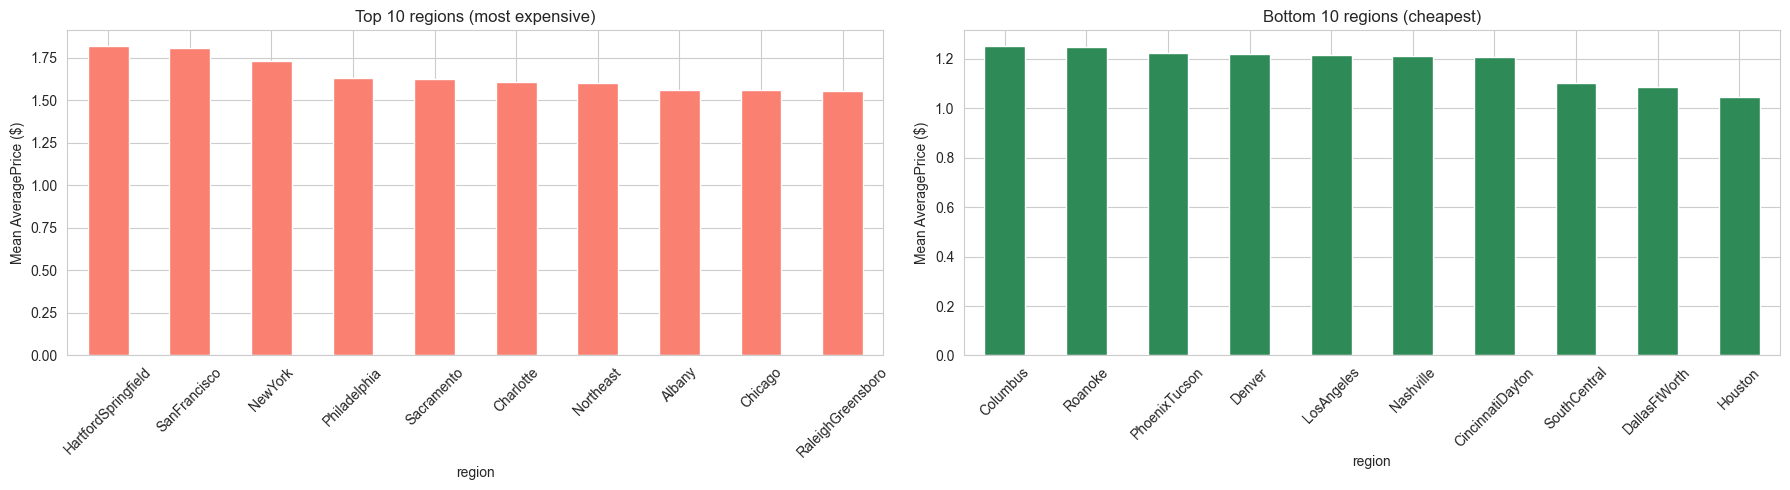

In [12]:
region_means = df.groupby("region")["AveragePrice"].mean().sort_values(ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
region_means.head(10).plot(kind="bar", color="salmon", ax=axes[0])
axes[0].set_title("Top 10 regions (most expensive)"); axes[0].tick_params(axis="x", rotation=45)
axes[0].set_ylabel("Mean AveragePrice ($)")

region_means.tail(10).plot(kind="bar", color="seagreen", ax=axes[1])
axes[1].set_title("Bottom 10 regions (cheapest)"); axes[1].tick_params(axis="x", rotation=45)
axes[1].set_ylabel("Mean AveragePrice ($)")
plt.tight_layout(); plt.show()

## 11. Correlation Analysis

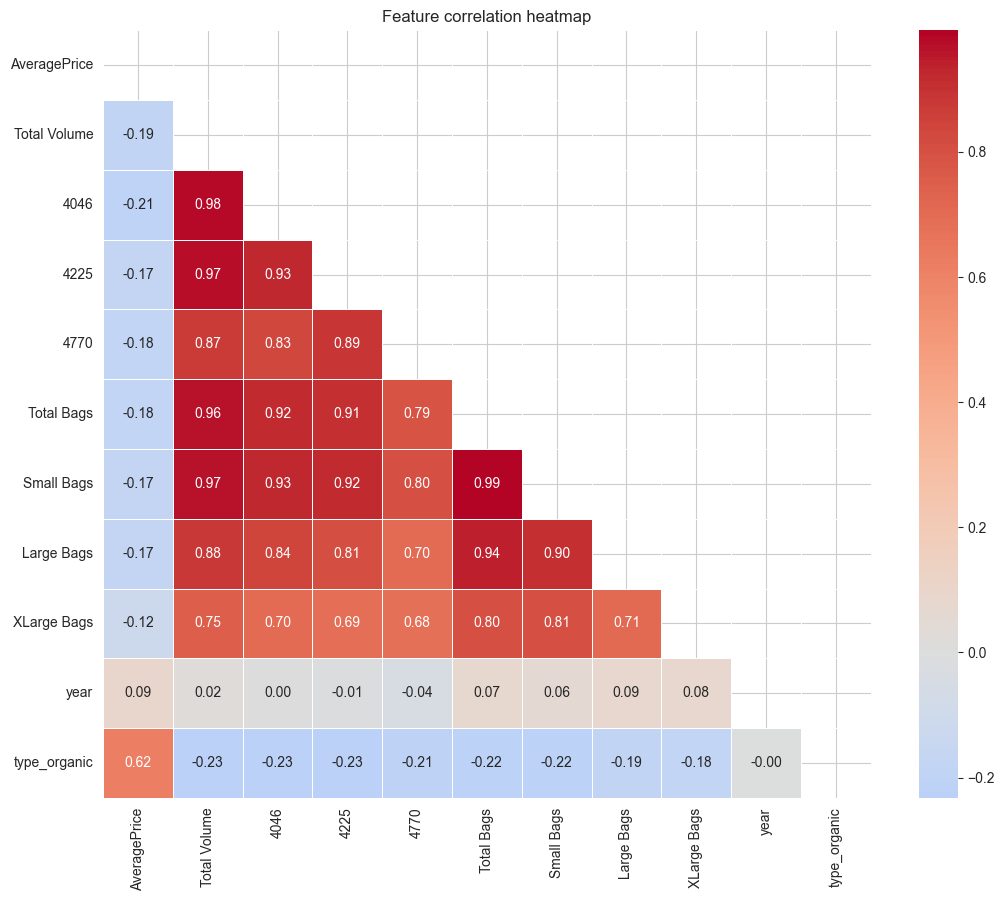

In [13]:
df_corr = df.copy()
df_corr["type_organic"] = (df_corr["type"] == "organic").astype(int)
plt.figure(figsize=(11, 9))
corr = df_corr.drop(columns=["Date","type","region"]).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5)
plt.title("Feature correlation heatmap")
plt.tight_layout(); plt.show()

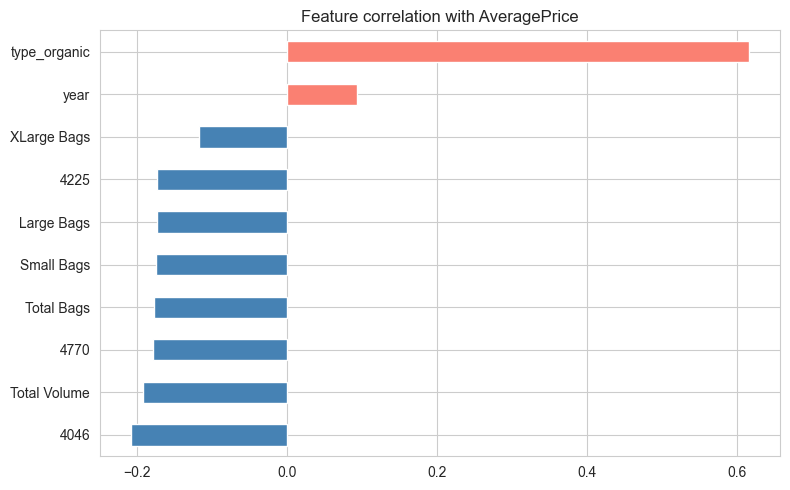

type_organic    0.616
year            0.093
XLarge Bags    -0.118
4225           -0.173
Large Bags     -0.173
Small Bags     -0.175
Total Bags     -0.177
4770           -0.179
Total Volume   -0.193
4046           -0.208
Name: AveragePrice, dtype: float64


In [14]:
target_corr = df_corr.drop(columns=["Date","type","region"]).corr()["AveragePrice"].drop("AveragePrice").sort_values(ascending=False)
plt.figure(figsize=(8, 5))
target_corr.plot(kind="barh",
                 color=["salmon" if x > 0 else "steelblue" for x in target_corr])
plt.title("Feature correlation with AveragePrice")
plt.gca().invert_yaxis()
plt.tight_layout(); plt.show()
print(target_corr.round(3))

## 12. Pair Plot — Top Predictors

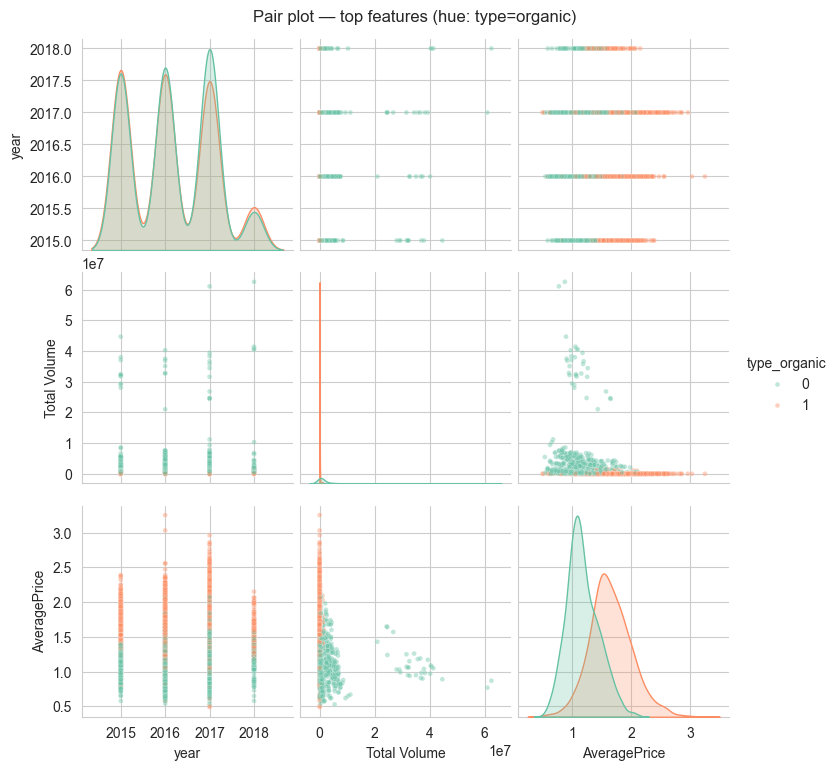

In [15]:
sample = df.sample(n=3000, random_state=42)
sample["type_organic"] = (sample["type"] == "organic").astype(int)
sns.pairplot(sample[["type_organic","year","Total Volume","AveragePrice"]],
             hue="type_organic", palette="Set2", diag_kind="kde",
             plot_kws={"alpha": 0.4, "s": 12})
plt.suptitle("Pair plot — top features (hue: type=organic)", y=1.02)
plt.show()

## 13. Key EDA Findings

| # | Finding |
|---|--------|
| 1 | **`type` is the dominant predictor** — organic avocados are ~50-60% more expensive than conventional, on average $1.65 vs $1.16 |
| 2 | **Volume is negatively correlated with price** — high-volume regions/weeks see lower per-unit prices (basic supply effect, but the magnitude is small: r ≈ −0.19) |
| 3 | **Year matters mildly** — 2017 had the highest mean prices, 2015 the lowest |
| 4 | **Region effects span ~$0.50** between cheapest (e.g. Houston, Phoenix-Tucson) and most expensive (e.g. SanFrancisco, NewYork) |
| 5 | **Volume features are heavily right-skewed** — log-transform recommended for linear models |
| 6 | **No missing values, no duplicates** — already clean |
| 7 | **Time-series structure**: the dataset has weekly observations 2015-2018 — for a serious model we'd want time-aware CV instead of random splits |